# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

Best k by silhouette score: 2


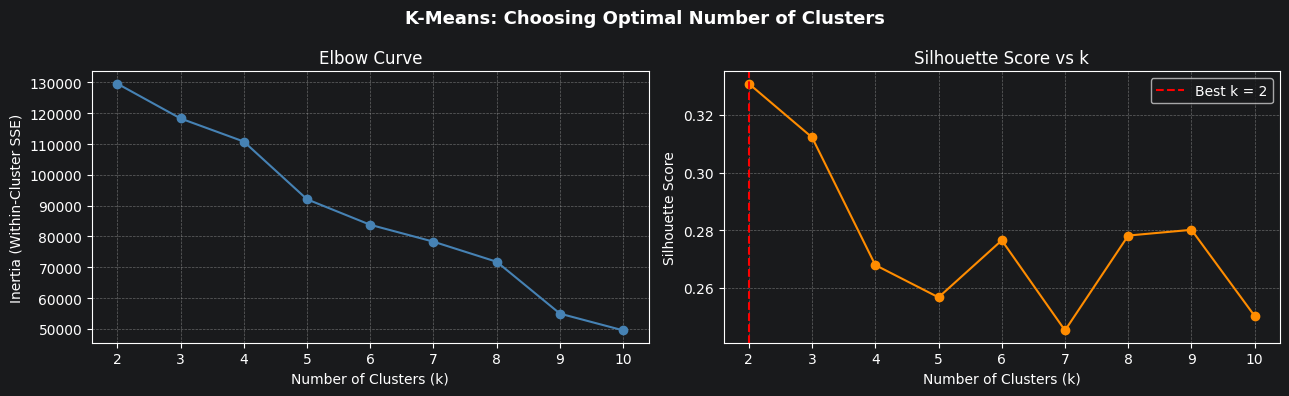

In [3]:

# --- Find Optimal K ---
k_results = find_optimal_k(X_scaled, k_range=range(2, 11))

best_k = k_results['best_k_silhouette']
print(f"Best k by silhouette score: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(k_results['k_range'], k_results['inertias'], marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette scores
axes[1].plot(k_results['k_range'], k_results['silhouette_scores'], marker='o', color='darkorange')
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


K-Means Results (k=2)
  Inertia:         129,613.2
  Silhouette:      0.3308

Cluster sizes:
Cluster
0    11963
1     8677

Cluster profiles (mean feature values):
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
Cluster                                                                                               
0         3.918    28.413     5.225      1.076    1532.242     3.098    33.946    -118.01        2.138
1         3.805    28.952     5.710      1.126    1278.280     3.033    37.957    -121.72        1.972


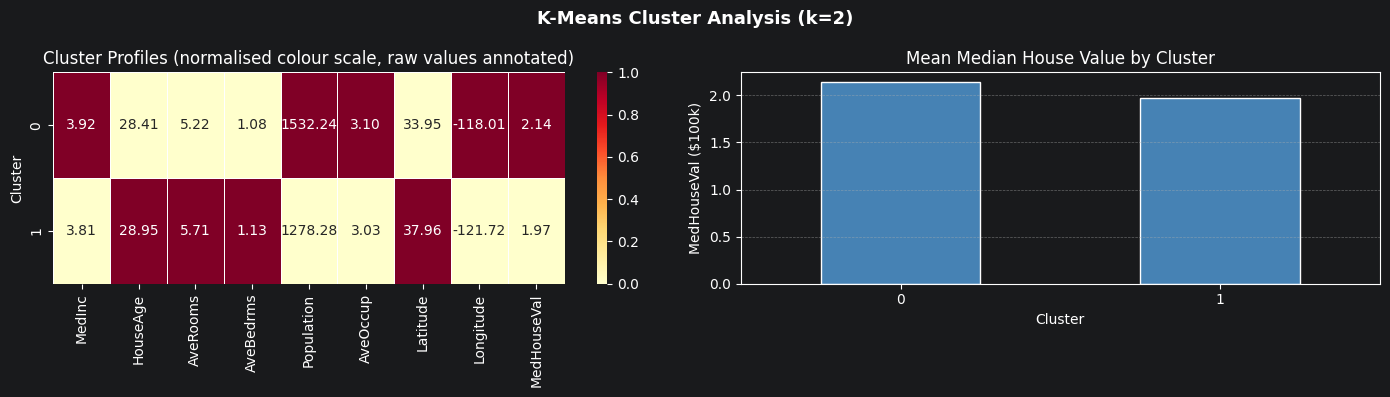

In [4]:

# --- K-Means with Optimal K ---
km_result = perform_kmeans(X_scaled, n_clusters=best_k)

print(f"K-Means Results (k={best_k})")
print(f"  Inertia:         {km_result['inertia']:,.1f}")
print(f"  Silhouette:      {km_result['silhouette']:.4f}")

# Attach cluster labels and target to a DataFrame for analysis
df_clusters = df.copy()
df_clusters['Cluster'] = km_result['labels']

# --- Cluster sizes ---
cluster_sizes = df_clusters['Cluster'].value_counts().sort_index()
print(f"\nCluster sizes:")
print(cluster_sizes.to_string())

# --- Cluster profiles: mean of each feature per cluster ---
profile_cols = feature_names + ['MedHouseVal']
cluster_profiles = df_clusters.groupby('Cluster')[profile_cols].mean().round(3)
print(f"\nCluster profiles (mean feature values):")
print(cluster_profiles.to_string())

# --- Visualise cluster profiles as a heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normalise each feature column to [0, 1] so the heatmap is comparable
profile_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min()
)
sns.heatmap(
    profile_norm,
    annot=cluster_profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Cluster Profiles (normalised colour scale, raw values annotated)')
axes[0].set_ylabel('Cluster')

# Bar chart: median house value per cluster
cluster_profiles['MedHouseVal'].plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Mean Median House Value by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('MedHouseVal ($100k)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'K-Means Cluster Analysis (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Hierarchical Clustering

In [ ]:
# TODO: Compute linkage matrix and plot dendrogram
# Use a subset for visualization (e.g., first 200 samples)

In [ ]:
# TODO: Perform hierarchical clustering
# Compare with K-Means results

## 4. DBSCAN Clustering

In [ ]:
# TODO: Tune DBSCAN parameters using tune_dbscan()
# Find best eps and min_samples

In [ ]:
# TODO: Run DBSCAN with best parameters
# Analyze noise points and clusters

## 5. PCA & Visualization

In [ ]:
# TODO: Perform PCA and plot explained variance
# Find optimal number of components for 95% variance

In [ ]:
# TODO: Use cluster_with_pca() for 2D visualization
# Create scatter plot colored by cluster labels

## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

In [ ]:
# TODO: Create cluster profile analysis

## Summary

TODO: Write a summary:
- Which clustering algorithm worked best for this data?
- How many natural market segments exist?
- What characterizes each segment?
- How did PCA help with visualization?